### This notebook is used to automate canadian airline passenger forecasting

In [ ]:
import requests
import json

### Operating and financial statistics for major Canadian airlines, monthly dataset PID:2310007901

In [57]:
payload = [{"productId":23100079}]

response = requests.post("https://www150.statcan.gc.ca/t1/wds/rest/getCubeMetadata", json=payload)

response.json()

[{'status': 'SUCCESS',
  'object': {'responseStatusCode': 0,
   'productId': '23100079',
   'cansimId': '401-0001',
   'cubeTitleEn': 'Operating and financial statistics for major Canadian airlines, monthly',
   'cubeTitleFr': "Statistiques d'exploitation et financières des principaux transporteurs aériens canadiens, mensuel",
   'cubeStartDate': '1981-01-01',
   'cubeEndDate': '2026-04-01',
   'frequencyCode': 6,
   'nbSeriesCube': 11,
   'nbDatapointsCube': 4676,
   'releaseTime': '2026-06-25T08:30',
   'archiveStatusCode': '2',
   'archiveStatusEn': 'CURRENT - a cube available to the public and that is current',
   'archiveStatusFr': 'ACTIF - un cube qui est disponible au public et qui est toujours mise a jour',
   'subjectCode': ['230105', '330305'],
   'surveyCode': ['5026'],
   'dimension': [{'dimensionPositionId': 1,
     'dimensionNameEn': 'Geography',
     'dimensionNameFr': 'Géographie',
     'hasUom': False,
     'member': [{'memberId': 1,
       'parentMemberId': None,
    

### Downloading and extracting the file from Stats Canada

In [58]:
response = requests.get("https://www150.statcan.gc.ca/t1/wds/rest/getFullTableDownloadCSV/23100079/en")
data = response.json()["object"]

print(data)

https://www150.statcan.gc.ca/n1/tbl/csv/23100079-eng.zip


In [59]:
download_zip = requests.get(data)

In [60]:
import zipfile
import io

with zipfile.ZipFile(io.BytesIO(download_zip.content)) as z:

    z.extractall("../dataset")

### Cleaning and Analysis

In [61]:
import pandas as pd

In [62]:
df = pd.read_csv("../dataset/23100079.csv")
df

,REF_DATE,GEO,DGUID,Operational and financial statistics,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1981-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.10,1895.0,NaN,NaN,NaN,0
1,1981-01,Canada,2021A000011124,Passenger-kilometres,Number,223,thousands,3,v11744,1.20,3411545.0,NaN,NaN,NaN,0
2,1981-01,Canada,2021A000011124,Kilograms of goods,Kilograms,192,thousands,3,v11745,1.30,29091.0,NaN,NaN,t,0
3,1981-01,Canada,2021A000011124,Goods tonne-kilometres,Tonne-kilometres,285,thousands,3,v11746,1.40,64084.0,NaN,NaN,t,0
4,1981-01,Canada,2021A000011124,Hours flown,Number,223,thousands,3,v11747,1.50,53.0,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4671,2026-04,Canada,2021A000011124,Available seat-kilometres,Number,223,thousands,3,v107645152,1.10,22986800.0,NaN,NaN,NaN,0
4672,2026-04,Canada,2021A000011124,Load factor,Percent,239,units,0,v107645153,1.11,84.8,NaN,NaN,NaN,1
4673,2026-04,Canada,2021A000011124,Hours flown,Number,223,thousands,3,v11747,1.50,185.0,NaN,NaN,NaN,0
4674,2026-04,Canada,2021A000011124,Turbo fuel consumed,Litres,203,thousands,3,v11748,1.60,630385.0,NaN,NaN,NaN,0


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4676 entries, 0 to 4675
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   REF_DATE                              4676 non-null   object 
 1   GEO                                   4676 non-null   object 
 2   DGUID                                 4676 non-null   object 
 3   Operational and financial statistics  4676 non-null   object 
 4   UOM                                   4676 non-null   object 
 5   UOM_ID                                4676 non-null   int64  
 6   SCALAR_FACTOR                         4676 non-null   object 
 7   SCALAR_ID                             4676 non-null   int64  
 8   VECTOR                                4676 non-null   object 
 9   COORDINATE                            4676 non-null   float64
 10  VALUE                                 4147 non-null   float64
 11  STATUS           

In [64]:
df = df[df["Operational and financial statistics"] == "Passengers"].reset_index(drop=True)
df

,REF_DATE,GEO,DGUID,Operational and financial statistics,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1981-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,1895.0,NaN,NaN,NaN,0
1,1981-02,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,1852.0,NaN,NaN,NaN,0
2,1981-03,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2130.0,NaN,NaN,NaN,0
3,1981-04,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2083.0,NaN,NaN,NaN,0
4,1981-05,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2118.0,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539,2025-12,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,7282.0,NaN,NaN,NaN,0
540,2026-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,6949.0,NaN,NaN,NaN,0
541,2026-02,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,6599.0,NaN,NaN,NaN,0
542,2026-03,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,7575.0,NaN,NaN,NaN,0


In [65]:
df["PASSENGERS"] = df["VALUE"]*1000
df

,REF_DATE,GEO,DGUID,Operational and financial statistics,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS,PASSENGERS
0,1981-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,1895.0,NaN,NaN,NaN,0,1895000.0
1,1981-02,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,1852.0,NaN,NaN,NaN,0,1852000.0
2,1981-03,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2130.0,NaN,NaN,NaN,0,2130000.0
3,1981-04,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2083.0,NaN,NaN,NaN,0,2083000.0
4,1981-05,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2118.0,NaN,NaN,NaN,0,2118000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539,2025-12,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,7282.0,NaN,NaN,NaN,0,7282000.0
540,2026-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,6949.0,NaN,NaN,NaN,0,6949000.0
541,2026-02,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,6599.0,NaN,NaN,NaN,0,6599000.0
542,2026-03,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,7575.0,NaN,NaN,NaN,0,7575000.0


In [66]:
df["REF_DATE"] = pd.to_datetime(df["REF_DATE"])
df = df.sort_values("REF_DATE")
df = df.set_index("REF_DATE")

In [67]:
df

,GEO,DGUID,Operational and financial statistics,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS,PASSENGERS
REF_DATE,,,,,,,,,,,,,,,
1981-01-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,1895.0,NaN,NaN,NaN,0,1895000.0
1981-02-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,1852.0,NaN,NaN,NaN,0,1852000.0
1981-03-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2130.0,NaN,NaN,NaN,0,2130000.0
1981-04-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2083.0,NaN,NaN,NaN,0,2083000.0
1981-05-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2118.0,NaN,NaN,NaN,0,2118000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,7282.0,NaN,NaN,NaN,0,7282000.0
2026-01-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,6949.0,NaN,NaN,NaN,0,6949000.0
2026-02-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,6599.0,NaN,NaN,NaN,0,6599000.0


In [68]:
df.drop(['GEO', 'DGUID', 'UOM', 'UOM_ID', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS', 'Operational and financial statistics', 'SCALAR_FACTOR', 'VALUE'],  axis=1, inplace=True)

In [69]:
df

,PASSENGERS
REF_DATE,
1981-01-01,1895000.0
1981-02-01,1852000.0
1981-03-01,2130000.0
1981-04-01,2083000.0
1981-05-01,2118000.0
...,...
2025-12-01,7282000.0
2026-01-01,6949000.0
2026-02-01,6599000.0


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 544 entries, 1981-01-01 to 2026-04-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   PASSENGERS  544 non-null    float64
dtypes: float64(1)
memory usage: 8.5 KB


In [71]:
df.isna().sum()

PASSENGERS    0
dtype: int64

In [72]:
df.index.is_monotonic_increasing

True

In [73]:
df["PASSENGERS"].describe()

count    5.440000e+02
mean     3.154877e+06
std      1.932101e+06
min      2.130000e+05
25%      1.831750e+06
50%      2.243000e+06
75%      3.529500e+06
max      8.463000e+06
Name: PASSENGERS, dtype: float64

In [74]:
df.tail()

,PASSENGERS
REF_DATE,
2025-12-01,7282000.0
2026-01-01,6949000.0
2026-02-01,6599000.0
2026-03-01,7575000.0
2026-04-01,7039000.0


# Visualization

In [75]:
import matplotlib.pyplot as plt

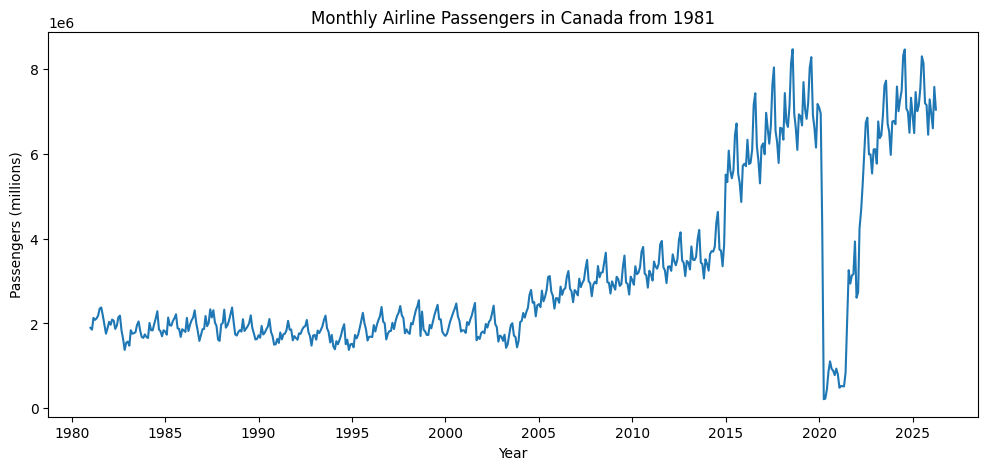

In [76]:
plt.figure(figsize= (12, 5))
plt.plot(df.index, df["PASSENGERS"])
plt.title("Monthly Airline Passengers in Canada from 1981")
plt.xlabel("Year")
plt.ylabel("Passengers (millions)")
plt.show()

### Modelling

In [77]:
from statsmodels.tsa.seasonal import seasonal_decompose

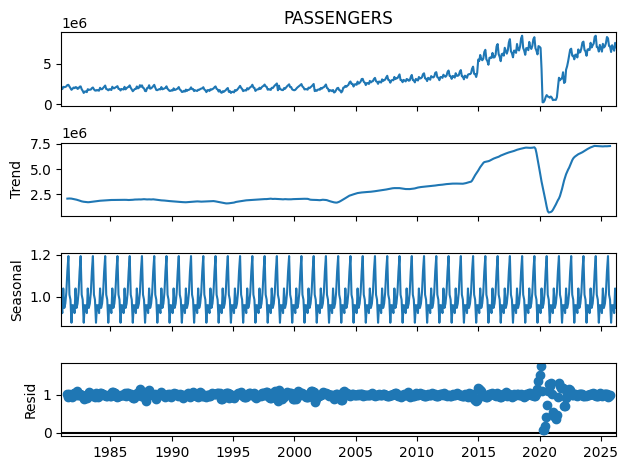

In [78]:
decompose = seasonal_decompose(df["PASSENGERS"], model="multiplicative", period=12)
decompose.plot()
plt.show()

In [79]:
from statsmodels.tsa.stattools import adfuller

In [80]:
adf_result = adfuller(df["PASSENGERS"])

print("ADF Statistics: ", adf_result[0])
print("p-value: ", adf_result[1])
print("Critical Values: ")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistics:  -1.6608223648304419
p-value:  0.4514025354617769
Critical Values: 
1%: -3.4428672600488066
5%: -2.8670609714890403
10%: -2.5697104770975057


In [81]:
df_sesnl = df["PASSENGERS"].diff(12).dropna()

In [82]:
adf_result = adfuller(df_sesnl)

print("ADF Statistics: ", adf_result[0])
print("p-value: ", adf_result[1])
print("Critical Values: ")
for key, value in adf_result[4].items():
    print(f" {key}: {value}")

ADF Statistics:  -5.930677310045664
p-value:  2.3847686008505025e-07
Critical Values: 
 1%: -3.443037261465839
 5%: -2.8671357972350493
 10%: -2.569750352856994


In [83]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

/var/folders/0z/g6c0qmm52072pt9jkpt9y58h0000gn/T/ipykernel_14389/3201995068.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


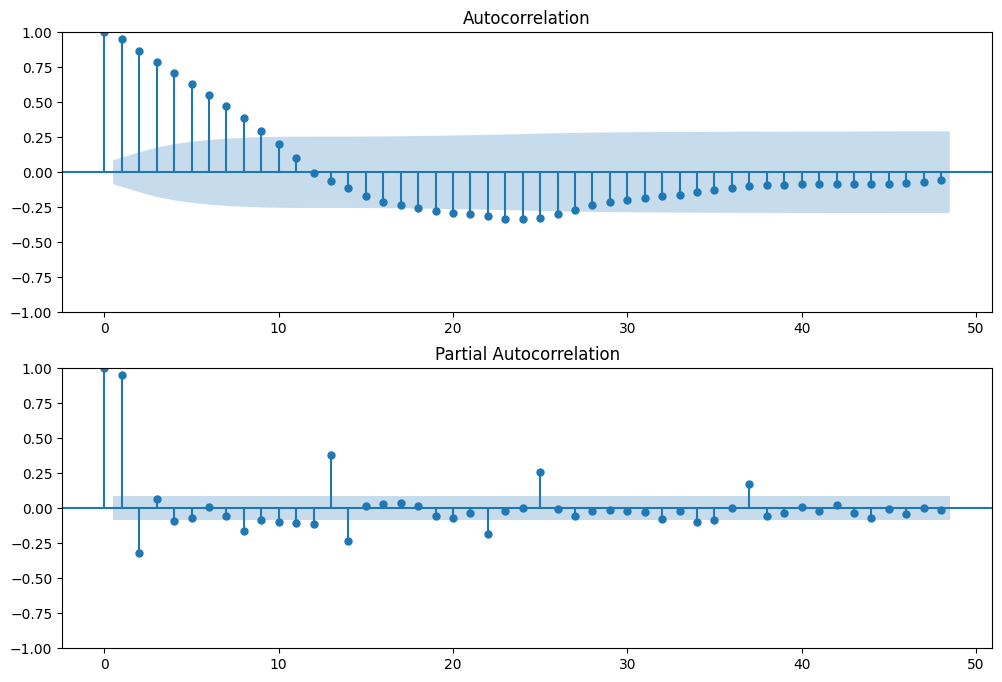

In [84]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df_sesnl, lags=48, ax=ax[0])
plot_pacf(df_sesnl, lags=48, ax=ax[1])
fig.show()

In [85]:
train = df.iloc[:-24]
test = df.iloc[-24:]

In [86]:
print(train.tail())

            PASSENGERS
REF_DATE              
2023-12-01   6757000.0
2024-01-01   6774000.0
2024-02-01   6696000.0
2024-03-01   7584000.0
2024-04-01   7001000.0


In [87]:
print(test.head())

            PASSENGERS
REF_DATE              
2024-05-01   7265000.0
2024-06-01   7491000.0
2024-07-01   8316000.0
2024-08-01   8457000.0
2024-09-01   7060000.0


In [88]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [89]:
model = SARIMAX(
    train["PASSENGERS"], order=(1, 0, 1),
    seasonal_order=(1, 1, 0, 12)
    )

/Users/naji/Documents/My Projects/aviation_forecasting_canada/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/naji/Documents/My Projects/aviation_forecasting_canada/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [90]:
model_fit = model.fit()
print(model_fit.params)

ar.L1       9.336023e-01
ma.L1       3.874171e-01
ar.S.L12   -4.307503e-01
sigma2      1.341787e+11
dtype: float64


In [91]:
print(model_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                          PASSENGERS   No. Observations:                  520
Model:             SARIMAX(1, 0, 1)x(1, 1, [], 12)   Log Likelihood               -7193.525
Date:                             Mon, 20 Jul 2026   AIC                          14395.050
Time:                                     12:38:35   BIC                          14411.972
Sample:                                 01-01-1981   HQIC                         14401.686
                                      - 04-01-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9336      0.009     99.474      0.000       0.915       0.952
ma.L1          0.3874      

In [92]:
forecast = model_fit.get_forecast(steps=24)
mean_forecast = forecast.predicted_mean
conf_int = forecast.conf_int()

### Testing the accuracy of the forecast

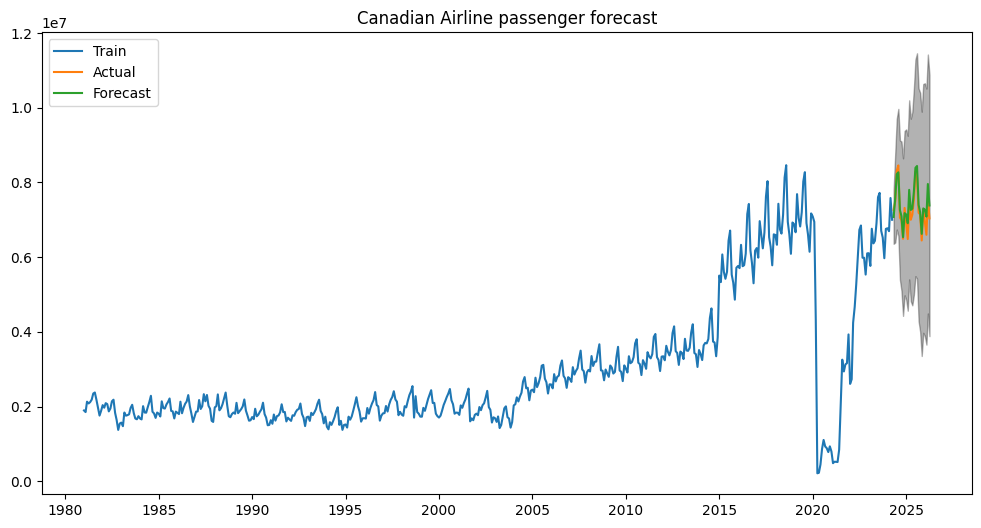

In [93]:
plt.figure(figsize=(12, 6))  
plt.plot(train.index, train["PASSENGERS"], label="Train")
plt.plot(test.index, test["PASSENGERS"], label="Actual")
plt.plot(mean_forecast.index, mean_forecast, label="Forecast")
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color="black", alpha=0.3)

plt.legend()
plt.title("Canadian Airline passenger forecast")
plt.show()

### Calculating MAPE and RMSE

In [94]:
from sklearn.metrics import mean_absolute_percentage_error

In [95]:
mape = mean_absolute_percentage_error(test["PASSENGERS"], mean_forecast)


In [96]:
print("MAPE: ", mape * 100)

MAPE:  2.977261108357514


In [97]:
from sklearn.metrics import mean_squared_error
import numpy as np

In [98]:
rmse = np.sqrt(mean_squared_error(test["PASSENGERS"], mean_forecast))

In [99]:
print("RMSE: ", rmse)

RMSE:  245978.62489646013


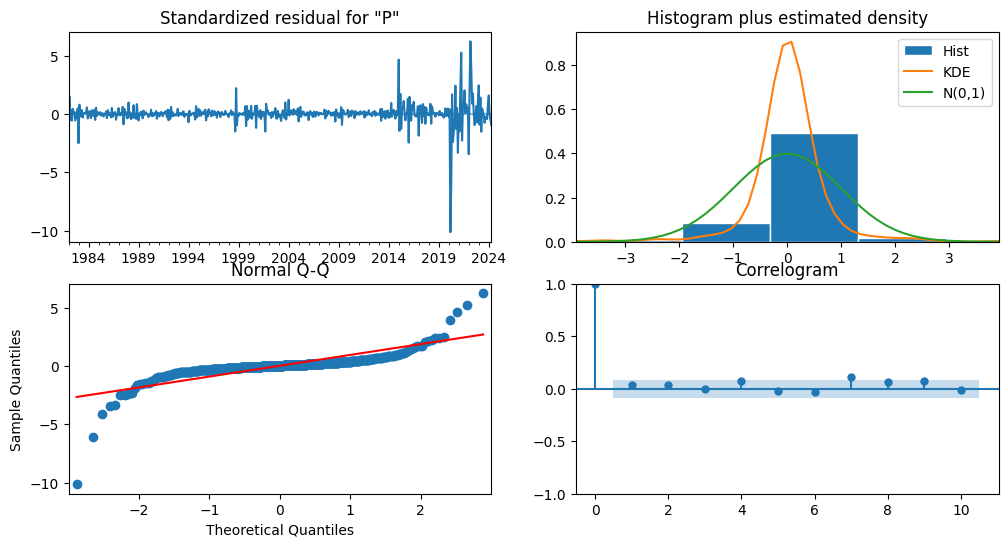

In [100]:
model_fit.plot_diagnostics(figsize=(12, 6))
plt.show()

In [101]:
final_model = SARIMAX(df["PASSENGERS"], order=(1, 0, 1), seasonal_order=(1, 1, 0, 12))

/Users/naji/Documents/My Projects/aviation_forecasting_canada/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/naji/Documents/My Projects/aviation_forecasting_canada/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


### Final Modelling

In [102]:
final_model_fit = final_model.fit()
print(final_model_fit.params)

ar.L1       9.330100e-01
ma.L1       3.811140e-01
ar.S.L12   -4.297413e-01
sigma2      1.302032e+11
dtype: float64


In [103]:
print(final_model_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                          PASSENGERS   No. Observations:                  544
Model:             SARIMAX(1, 0, 1)x(1, 1, [], 12)   Log Likelihood               -7525.340
Date:                             Mon, 20 Jul 2026   AIC                          15058.681
Time:                                     12:38:36   BIC                          15075.787
Sample:                                 01-01-1981   HQIC                         15065.375
                                      - 04-01-2026                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9330      0.009    102.747      0.000       0.915       0.951
ma.L1          0.3811      

In [104]:
automated_forecasted_data = final_model_fit.get_forecast(steps=24)
mean_future_forecast = automated_forecasted_data.predicted_mean
future_conf_int = automated_forecasted_data.conf_int()

### Future Forecast

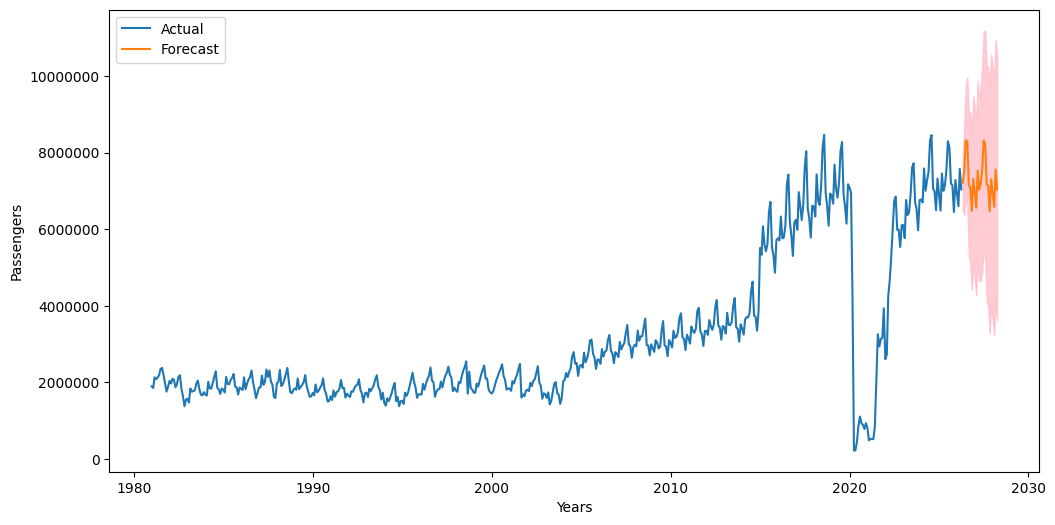

In [105]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["PASSENGERS"], label="Actual")
plt.plot(mean_future_forecast.index, mean_future_forecast, label="Forecast")
plt.fill_between(future_conf_int.index, future_conf_int.iloc[:,0], future_conf_int.iloc[:,1], color="pink", alpha=0.8)
plt.ticklabel_format(style='plain', axis='y')
plt.ylabel("Passengers")
plt.xlabel("Years")
plt.legend()
plt.savefig("../plots/automated_forecast.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [106]:
automated_forecasted_data = pd.concat([mean_future_forecast, future_conf_int], axis=1)
automated_forecasted_data.columns = ["Forecast", "Lower_ci", "Upper_ci"]

In [107]:
automated_forecasted_data.tail(40)

,Forecast,Lower_ci,Upper_ci
2026-05-01,7.210795e+06,6.503568e+06,7.918022e+06
2026-06-01,7.539893e+06,6.372021e+06,8.707765e+06
2026-07-01,8.320950e+06,6.866360e+06,9.775539e+06
2026-08-01,8.289776e+06,6.625334e+06,9.954219e+06
2026-09-01,7.147230e+06,5.319622e+06,8.974838e+06
2026-10-01,7.093244e+06,5.134634e+06,9.051853e+06
2026-11-01,6.479162e+06,4.413267e+06,8.545056e+06
2026-12-01,7.309464e+06,5.154520e+06,9.464407e+06
2027-01-01,6.940450e+06,4.710883e+06,9.170017e+06
2027-02-01,6.560505e+06,4.267954e+06,8.853056e+06


### Forecast CSV

In [110]:
automated_forecasted_data.to_csv('../dataset/auto_forecast_data.csv')